<a href="https://colab.research.google.com/github/sulucay01/DI725-assignment1/blob/dev/notebooks/04_modeling_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Weights & Biases: https://wandb.ai/selingoktas98-metu-middle-east-technical-university/di725-assignment1?nw=nwuserselingoktas98

https://wandb.ai/selingoktas98-metu-middle-east-technical-university/di725-assignment1-sweep?nw=nwuserselingoktas98

GitHub: https://github.com/sulucay01/DI725-assignment1

# Objective of the notebook

This notebook builds and evaluates a fusion-based sentiment classification model.

The main goals are:
- Construct a fusion model by combining text, categorical, and numerical features
- Evaluate model performance on the test set
- Analyze performance on the minority (positive) class
- Examine the impact of oversampling and class-weighted loss
- Apply small fine-tuning adjustments to improve stability
- Select the best final model based on macro F1 and class-wise performance

In [ ]:
# =========================================================
# Imports
# =========================================================

import os
import re
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import wandb
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import f_classif
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

from torch.utils.data import Dataset

In [ ]:
# =========================================================
# Reproducibility and experiment configuration
# =========================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

# Reset all random seeds before each experiment so that
# model initialization, sampling, and training behavior
# remain consistent across runs.

def reset_all_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    set_seed(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

MODEL_NAME = "roberta-base"
MAX_LENGTH = 512
OVERSAMPLE_FACTOR = 3

WANDB_PROJECT = "di725-assignment1"

SPECIAL_TOKENS = ["[CUSTOMER]", "[AGENT]", "[EMAIL]", "[PHONE]", "[ID]"]

CATEGORICAL_COLS = ["issue_area", "issue_category"]

CAT_EMB_DIM = 32
NUM_HIDDEN_DIM = 64
FUSION_HIDDEN_DIM = 256
DROPOUT = 0.2

LR = 2e-5
EPOCHS = 3
TRAIN_BS = 8
EVAL_BS = 16

reset_all_seeds(SEED)

Seed set to: 42
CUDA available: True


In [ ]:
# =========================================================
# Load processed datasets
# =========================================================

# Load the finalized processed train / validation / test splits
# from the GitHub repository.
train_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/train_processed.csv")
val_df   = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/val_processed.csv")
test_df  = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/test_processed.csv")

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["clean_text"].fillna("").astype(str)
    df["issue_area"] = df["issue_area"].fillna("UNKNOWN").astype(str)
    df["issue_category"] = df["issue_category"].fillna("UNKNOWN").astype(str)

train: (773, 13)
val:   (194, 13)
test:  (30, 13)


In [ ]:
# =========================================================
# Encode target labels
# =========================================================

# Fit the target label encoder on the training split only.
# Validation and test splits are transformed using the same mapping.
label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["customer_sentiment"])
val_df["label"]   = label_encoder.transform(val_df["customer_sentiment"])
test_df["label"]  = label_encoder.transform(test_df["customer_sentiment"])

label_mapping = {cls: int(i) for i, cls in enumerate(label_encoder.classes_)}
print("Label mapping:", label_mapping)
print(train_df["customer_sentiment"].value_counts())


Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
customer_sentiment
neutral     433
negative    326
positive     14
Name: count, dtype: int64


In [ ]:
# =========================================================
# Encode categorical structured features
# =========================================================

# Each categorical feature is encoded with a train-fit-only label encoder.
# Any unseen category in validation or test is mapped to "UNKNOWN".
cat_encoders = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    le.fit(train_df[col])

    known_classes = set(le.classes_)

    if "UNKNOWN" not in known_classes:
        le.classes_ = np.append(le.classes_, "UNKNOWN")
        known_classes = set(le.classes_)

    train_df[col] = train_df[col].apply(lambda x: x if x in known_classes else "UNKNOWN")
    val_df[col]   = val_df[col].apply(lambda x: x if x in known_classes else "UNKNOWN")
    test_df[col]  = test_df[col].apply(lambda x: x if x in known_classes else "UNKNOWN")

    train_df[f"{col}_id"] = le.transform(train_df[col])
    val_df[f"{col}_id"]   = le.transform(val_df[col])
    test_df[f"{col}_id"]  = le.transform(test_df[col])

    cat_encoders[col] = le

print("issue_area classes:", len(cat_encoders["issue_area"].classes_))
print("issue_category classes:", len(cat_encoders["issue_category"].classes_))

issue_area classes: 7
issue_category classes: 41


In [ ]:
# =========================================================
# Tokenizer setup
# =========================================================

# Initialize tokenizer and add custom special tokens
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
tokenizer.add_special_tokens({"additional_special_tokens": SPECIAL_TOKENS})

# Tail truncation: keep last tokens of long conversations
def truncate_text_tail(text, tokenizer, max_length=512):
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    budget = max_length - 2

    if len(token_ids) <= budget:
        return text

    truncated_ids = token_ids[-budget:]
    return tokenizer.decode(
        truncated_ids,
        skip_special_tokens=False,
        clean_up_tokenization_spaces=True
    )

# Apply truncation to all splits
for df in [train_df, val_df, test_df]:
    df["model_text"] = df["clean_text"].apply(
        lambda x: truncate_text_tail(x, tokenizer, max_length=MAX_LENGTH)
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (514 > 512). Running this sequence through the model will result in indexing errors


In [ ]:
# =========================================================
# Candidate numerical feature engineering
# =========================================================

# Numerical features are extracted from the full cleaned conversation
# (clean_text) rather than the truncated model_text.
#
# The transformer branch uses tail-truncated text, while the numerical
# branch is designed to capture global conversation characteristics
# such as length, turn structure, speaker contribution, and lexical patterns.

def extract_numeric_features(df, text_col="clean_text"):
    """
    Creates global numerical features from the full cleaned conversation.

    The transformer branch still uses truncated model_text, while the
    numerical branch carries whole-conversation statistics.
    """
    out = df.copy()
    text_series = out[text_col].fillna("").astype(str)

    # -----------------------------------------------------
    # Basic conversation size
    # -----------------------------------------------------
    out["num_words"] = text_series.apply(lambda x: len(x.split()))
    out["num_chars"] = text_series.str.len()
    out["avg_word_len"] = text_series.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0.0
    )

    # -----------------------------------------------------
    # Simple expressive style
    # -----------------------------------------------------
    out["question_mark_count"] = text_series.str.count(r"\?")
    out["exclamation_count"] = text_series.str.count(r"!")

    # -----------------------------------------------------
    # Turn structure
    # -----------------------------------------------------
    out["customer_turn_count"] = text_series.str.count(r"\[CUSTOMER\]")
    out["agent_turn_count"] = text_series.str.count(r"\[AGENT\]")
    out["total_turn_count"] = out["customer_turn_count"] + out["agent_turn_count"]

    # -----------------------------------------------------
    # Turn-length statistics
    # -----------------------------------------------------
    def split_turns(text):
        turns = re.split(r"\[CUSTOMER\]|\[AGENT\]", text)
        return [t.strip() for t in turns if t.strip()]

    def turn_word_lengths(text):
        turns = split_turns(text)
        return [len(t.split()) for t in turns]

    turn_lengths = text_series.apply(turn_word_lengths)

    out["avg_words_per_turn"] = turn_lengths.apply(
        lambda x: np.mean(x) if len(x) > 0 else 0.0
    )
    out["std_turn_len_words"] = turn_lengths.apply(
        lambda x: np.std(x) if len(x) > 0 else 0.0
    )

    # -----------------------------------------------------
    # Speaker-specific volume
    # -----------------------------------------------------
    def get_speaker_text(text, speaker_token):
        pattern = rf"{re.escape(speaker_token)}(.*?)(?=\[CUSTOMER\]|\[AGENT\]|$)"
        matches = re.findall(pattern, text, flags=re.DOTALL)
        return [m.strip() for m in matches if m.strip()]

    def speaker_word_count(text, speaker_token):
        segments = get_speaker_text(text, speaker_token)
        return sum(len(seg.split()) for seg in segments)

    out["customer_word_count"] = text_series.apply(
        lambda x: speaker_word_count(x, "[CUSTOMER]")
    )
    out["agent_word_count"] = text_series.apply(
        lambda x: speaker_word_count(x, "[AGENT]")
    )

    # -----------------------------------------------------
    # Lexical variety
    # -----------------------------------------------------
    out["unique_word_count"] = text_series.apply(lambda x: len(set(x.split())))
    out["lexical_diversity"] = np.where(
        out["num_words"] > 0,
        out["unique_word_count"] / out["num_words"],
        0.0
    )

    out = out.replace([np.inf, -np.inf], 0)

    return out

In [ ]:
# Create candidate numerical features on each split
train_df = extract_numeric_features(train_df, text_col="clean_text")
val_df = extract_numeric_features(val_df, text_col="clean_text")
test_df = extract_numeric_features(test_df, text_col="clean_text")

In [ ]:
# Group candidate numerical features by type.
NUMERIC_FEATURE_GROUPS = {
    "conversation_size": [
        "num_words",
        "num_chars",
        "avg_word_len"
    ],
    "style": [
        "question_mark_count",
        "exclamation_count"
    ],
    "turn_structure": [
        "customer_turn_count",
        "agent_turn_count",
        "total_turn_count",
        "avg_words_per_turn",
        "std_turn_len_words"
    ],
    "speaker_volume": [
        "customer_word_count",
        "agent_word_count"
    ],
    "lexical": [
        "unique_word_count",
        "lexical_diversity"
    ]
}

ALL_NUMERIC_COLS = [
    col
    for cols in NUMERIC_FEATURE_GROUPS.values()
    for col in cols
]

print("Number of candidate numerical features:", len(ALL_NUMERIC_COLS))
print(ALL_NUMERIC_COLS)

print("\nCandidate numerical feature preview:")
display(train_df[ALL_NUMERIC_COLS].head())

Number of candidate numerical features: 14
['num_words', 'num_chars', 'avg_word_len', 'question_mark_count', 'exclamation_count', 'customer_turn_count', 'agent_turn_count', 'total_turn_count', 'avg_words_per_turn', 'std_turn_len_words', 'customer_word_count', 'agent_word_count', 'unique_word_count', 'lexical_diversity']

Candidate numerical feature preview:


,num_words,num_chars,avg_word_len,question_mark_count,exclamation_count,customer_turn_count,agent_turn_count,total_turn_count,avg_words_per_turn,std_turn_len_words,customer_word_count,agent_word_count,unique_word_count,lexical_diversity
0,419,2286,4.458234,8,2,7,9,16,25.187500,15.042518,104,299,200,0.477327
1,359,2100,4.852368,6,0,9,11,20,16.950000,10.988517,76,263,173,0.481894
2,473,2708,4.727273,7,1,10,12,22,20.500000,13.819453,108,343,189,0.399577
3,373,2123,4.694370,4,3,7,8,15,23.866667,16.512083,83,275,192,0.514745
4,350,1947,4.565714,4,3,9,10,19,17.421053,14.946627,88,243,182,0.520000


In [ ]:
# =========================================================
# Analyze candidate numerical features on training split
# =========================================================

# Numerical features are evaluated using only the training split to avoid
# data leakage.
#
# Two main criteria are used:
# 1. ANOVA F-score (p-values): measures how well each feature separates
#    sentiment classes.
# 2. Correlation analysis: identifies redundant features.
#
# The goal is not to fully automate selection, but to support a
# statistically grounded and interpretable feature choice.

def summarize_numeric_features(train_df, numeric_cols, label_col="label"):
    """
    Creates a compact summary table for candidate numerical features
    using the training split only.
    """
    X = train_df[numeric_cols].copy()
    y = train_df[label_col].values

    f_vals, p_vals = f_classif(X, y)

    summary_df = pd.DataFrame({
        "feature": numeric_cols,
        "mean": X.mean().values,
        "std": X.std().values,
        "zero_ratio": (X == 0).mean().values,
        "f_score": f_vals,
        "p_value": p_vals
    })

    return summary_df.sort_values("f_score", ascending=False).reset_index(drop=True)


def show_classwise_stats(train_df, feature, target_col="customer_sentiment"):
    """
    Shows class-wise mean and median for one feature.
    """
    return (
        train_df.groupby(target_col)[feature]
        .agg(["mean", "median"])
        .round(4)
    )

In [ ]:
numeric_summary_df = summarize_numeric_features(
    train_df=train_df,
    numeric_cols=ALL_NUMERIC_COLS,
    label_col="label"
)

print("Candidate numerical feature summary:")
display(numeric_summary_df)

Candidate numerical feature summary:


,feature,mean,std,zero_ratio,f_score,p_value
0,num_words,371.107374,95.525165,0.000000,97.412657,1.932786e-38
1,num_chars,2122.855110,546.283714,0.000000,96.109796,5.474744e-38
2,agent_word_count,244.551100,62.906103,0.000000,87.155817,7.577454e-35
3,unique_word_count,176.940492,27.680198,0.000000,85.467792,3.008641e-34
4,lexical_diversity,0.489831,0.059999,0.000000,67.574540,9.155569e-28
5,total_turn_count,17.134541,3.526731,0.000000,51.660022,8.854410e-22
6,customer_turn_count,8.069858,1.950896,0.000000,42.382607,3.450609e-18
7,agent_turn_count,9.064683,1.949082,0.000000,40.476173,1.929354e-17
8,question_mark_count,6.560155,1.946317,0.000000,25.508736,1.876098e-11
9,avg_words_per_turn,20.775760,4.069443,0.000000,25.427634,2.024380e-11


In [ ]:
# =========================================================
# Feature selection
# =========================================================

# Step 1: filter by statistical significance
significant_features = numeric_summary_df[
    numeric_summary_df["p_value"] < 0.05
]["feature"].tolist()

print("Significant features:", significant_features)

Significant features: ['num_words', 'num_chars', 'agent_word_count', 'unique_word_count', 'lexical_diversity', 'total_turn_count', 'customer_turn_count', 'agent_turn_count', 'question_mark_count', 'avg_words_per_turn', 'customer_word_count', 'exclamation_count', 'std_turn_len_words']


In [ ]:
# Step 2: remove highly correlated features

# A correlation threshold (e.g., 0.7) is applied to remove
# highly redundant features.
#
# This ensures the final feature set remains compact while
# preserving diverse and complementary signals.

def remove_high_corr_features(df, features, threshold=0.70):
    corr_matrix = df[features].corr().abs()
    selected = []

    for col in features:
        keep = True
        for sel in selected:
            if corr_matrix.loc[col, sel] > threshold:
                keep = False
                break
        if keep:
            selected.append(col)

    return selected


filtered_features = remove_high_corr_features(
    train_df,
    significant_features,
    threshold=0.70
)

print("Filtered features after correlation check:", filtered_features)

Filtered features after correlation check: ['num_words', 'total_turn_count', 'question_mark_count', 'avg_words_per_turn', 'exclamation_count']


In [ ]:
SELECTED_NUMERIC_COLS =  [
    'num_words',
    'total_turn_count',
    'question_mark_count',
    'avg_words_per_turn',
    'exclamation_count' ]

In [ ]:
# =========================================================
# Standardize selected numerical features
# =========================================================

# Numerical features are standardized using statistics from the
# training split only. The same transformation is applied to
# validation and test sets.

scaler = StandardScaler()

train_df[SELECTED_NUMERIC_COLS] = scaler.fit_transform(train_df[SELECTED_NUMERIC_COLS])
val_df[SELECTED_NUMERIC_COLS]   = scaler.transform(val_df[SELECTED_NUMERIC_COLS])
test_df[SELECTED_NUMERIC_COLS]  = scaler.transform(test_df[SELECTED_NUMERIC_COLS])

In [ ]:
# =========================================================
# Oversample minority class in training split only
# =========================================================

# Oversampling is applied only to the training split.
# Validation and test sets must remain unchanged so that evaluation
# reflects the original class distribution.

# Get the encoded label id for the positive class.
label_map_df = (
    train_df[["customer_sentiment", "label"]]
    .drop_duplicates()
    .sort_values("label")
)

positive_label_id = label_map_df.loc[
    label_map_df["customer_sentiment"].str.lower() == "positive", "label"
].iloc[0]

print("Positive label id:", positive_label_id)

print("Original training class distribution:")
print(train_df["label"].value_counts().sort_index())

train_majority_part = train_df[train_df["label"] != positive_label_id].copy()
train_positive_part = train_df[train_df["label"] == positive_label_id].copy()

reset_all_seeds(SEED)

# Bootstrap oversampling (positive class)
train_positive_oversampled = resample(
    train_positive_part,
    replace=True,
    n_samples=len(train_positive_part) * OVERSAMPLE_FACTOR,
    random_state=SEED
)

train_os_df = pd.concat(
    [train_majority_part, train_positive_oversampled],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nOversampled training class distribution:")
print(train_os_df["label"].value_counts().sort_index())

Positive label id: 2
Original training class distribution:
label
0    326
1    433
2     14
Name: count, dtype: int64

Oversampled training class distribution:
label
0    326
1    433
2     42
Name: count, dtype: int64


In [ ]:
# =========================================================
# Tokenize text inputs
# =========================================================

# Tokenize `model_text` for train/validation/test using the tail truncation strategy.

def tokenize_dataframe_text(df, tokenizer, max_length=512):
    return tokenizer(
        df["model_text"].tolist(),
        truncation=True,
        max_length=max_length,
        padding=False
    )

# Train uses oversampled rows, validation and test keep original distributions.
train_encodings = tokenize_dataframe_text(train_os_df, tokenizer, MAX_LENGTH)
val_encodings   = tokenize_dataframe_text(val_df, tokenizer, MAX_LENGTH)
test_encodings  = tokenize_dataframe_text(test_df, tokenizer, MAX_LENGTH)

In [ ]:
# =========================================================
# Custom dataset for fusion model
# =========================================================

# Create a flexible dataset/collator that can support:
# - text + categorical
# - text + numerical
# - text + categorical + numerical

class FlexibleFusionDataset(Dataset):
    def __init__(self, encodings, labels, cat_features=None, num_features=None):
        self.encodings = encodings
        self.labels = labels.astype(np.int64)
        self.cat_features = cat_features.astype(np.int64) if cat_features is not None else None
        self.num_features = num_features.astype(np.float32) if num_features is not None else None

    def __len__(self):
        return len(self.labels)

    # Return text inputs and optional structured features for one sample.
    def __getitem__(self, idx):
        item = {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }

        if self.cat_features is not None:
            item["cat_features"] = self.cat_features[idx]

        if self.num_features is not None:
            item["num_features"] = self.num_features[idx]

        return item

class FlexibleFusionCollator:
    def __init__(self, tokenizer):
        self.base_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Pad text inputs dynamically and stack structured features separately.
    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.base_collator(text_features)

        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        if "cat_features" in features[0]:
            batch["cat_features"] = torch.tensor(
                [f["cat_features"] for f in features],
                dtype=torch.long
            )

        if "num_features" in features[0]:
            batch["num_features"] = torch.tensor(
                [f["num_features"] for f in features],
                dtype=torch.float
            )

        return batch

In [ ]:
# =========================================================
# Compute class weights
# =========================================================
# Use the original training distribution to compute class weights for the loss.

class_labels = np.sort(train_df["label"].unique())

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=train_df["label"].values
)

class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float)
print("Class weights:", class_weights_tensor)

Class weights: tensor([ 0.7904,  0.5951, 18.4048])


In [ ]:
# =========================================================
# Fusion model
# =========================================================

# Build a flexible RoBERTa-based architecture that can combine text
# representations with categorical embeddings and/or projected numerical features.

class RobertaFlexibleFusionClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels,
        class_weights,
        tokenizer_len,
        use_categorical=False,
        use_numerical=False,
        issue_area_cardinality=None,
        issue_category_cardinality=None,
        num_numeric_features=None,
        cat_emb_dim=32,
        num_hidden_dim=64,
        fusion_hidden_dim=256,
        dropout=0.2
    ):
        super().__init__()

        self.use_categorical = use_categorical
        self.use_numerical = use_numerical

        self.text_encoder = AutoModel.from_pretrained(model_name)
        self.text_encoder.resize_token_embeddings(tokenizer_len)

        text_hidden_size = self.text_encoder.config.hidden_size
        extra_dim = 0

        if self.use_categorical:
            self.issue_area_embedding = nn.Embedding(issue_area_cardinality, cat_emb_dim)
            self.issue_category_embedding = nn.Embedding(issue_category_cardinality, cat_emb_dim)
            extra_dim += 2 * cat_emb_dim

        if self.use_numerical:
            self.num_projection = nn.Sequential(
                nn.Linear(num_numeric_features, num_hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            )
            extra_dim += num_hidden_dim

        fusion_input_dim = text_hidden_size + extra_dim

        self.fusion_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fusion_input_dim, fusion_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim, num_labels)
        )

        self.class_weights = class_weights

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        cat_features=None,
        num_features=None,
        labels=None
    ):

        # Encode text and use the first token representation as sentence-level text embedding.
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_repr = outputs.last_hidden_state[:, 0, :]

        fusion_parts = [text_repr]

        if self.use_categorical:
            issue_area_ids = cat_features[:, 0]
            issue_category_ids = cat_features[:, 1]

            issue_area_repr = self.issue_area_embedding(issue_area_ids)
            issue_category_repr = self.issue_category_embedding(issue_category_ids)

            fusion_parts.extend([issue_area_repr, issue_category_repr])

        if self.use_numerical:
            num_repr = self.num_projection(num_features)
            fusion_parts.append(num_repr)

        # Concatenate text with optional categorical and numerical representations.
        fused_repr = torch.cat(fusion_parts, dim=1)
        logits = self.fusion_head(fused_repr)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}


In [ ]:
# =========================================================
# Evaluation metrics
# =========================================================

# Track macro-F1, weighted-F1, accuracy, confusion matrices, and positive-class metrics.

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

def evaluate_split(trainer, dataset, split_name, label_encoder):
    preds_output = trainer.predict(dataset)
    logits = preds_output.predictions
    y_true = preds_output.label_ids
    y_pred = np.argmax(logits, axis=1)

    label_names = list(label_encoder.classes_)

    print(f"\n{'='*60}")
    print(f"{split_name.upper()} CLASSIFICATION REPORT")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{split_name.upper()} CONFUSION MATRIX")
    print(cm)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "confusion_matrix": cm
    }

def get_positive_class_metrics(y_true, y_pred, label_encoder, positive_label="positive"):
    pos_idx = list(label_encoder.classes_).index(positive_label)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[pos_idx],
        average=None,
        zero_division=0
    )

    return {
        "precision": precision[0],
        "recall": recall[0],
        "f1": f1[0]
    }

In [ ]:
# =========================================================
# Experiment runner
# =========================================================

# Create a reusable training function for all fusion configurations.

def run_experiment(
    experiment_name,
    use_categorical=False,
    use_numerical=False
):
    wandb.init(
        project=WANDB_PROJECT,
        name=experiment_name,
        reinit=True,
        config={
            "model_name": MODEL_NAME,
            "max_length": MAX_LENGTH,
            "oversample_factor": OVERSAMPLE_FACTOR,
            "use_categorical": use_categorical,
            "use_numerical": use_numerical,
            "categorical_features": CATEGORICAL_COLS if use_categorical else [],
            "numerical_features": SELECTED_NUMERIC_COLS if use_numerical else [],
            "cat_emb_dim": CAT_EMB_DIM,
            "num_hidden_dim": NUM_HIDDEN_DIM,
            "fusion_hidden_dim": FUSION_HIDDEN_DIM,
            "dropout": DROPOUT,
            "learning_rate": LR,
            "epochs": EPOCHS,
            "train_batch_size": TRAIN_BS,
            "eval_batch_size": EVAL_BS,
            "truncation": "tail",
            "special_tokens": SPECIAL_TOKENS
        }
    )

    # Build arrays
    train_cat = train_os_df[["issue_area_id", "issue_category_id"]].values if use_categorical else None
    val_cat   = val_df[["issue_area_id", "issue_category_id"]].values if use_categorical else None

    train_num = train_os_df[SELECTED_NUMERIC_COLS].values if use_numerical else None
    val_num   = val_df[SELECTED_NUMERIC_COLS].values if use_numerical else None

    train_dataset = FlexibleFusionDataset(
        encodings=train_encodings,
        labels=train_os_df["label"].values,
        cat_features=train_cat,
        num_features=train_num
    )

    val_dataset = FlexibleFusionDataset(
        encodings=val_encodings,
        labels=val_df["label"].values,
        cat_features=val_cat,
        num_features=val_num
    )

    model = RobertaFlexibleFusionClassifier(
        model_name=MODEL_NAME,
        num_labels=len(class_labels),
        class_weights=class_weights_tensor,
        tokenizer_len=len(tokenizer),
        use_categorical=use_categorical,
        use_numerical=use_numerical,
        issue_area_cardinality=len(cat_encoders["issue_area"].classes_) if use_categorical else None,
        issue_category_cardinality=len(cat_encoders["issue_category"].classes_) if use_categorical else None,
        num_numeric_features=len(SELECTED_NUMERIC_COLS) if use_numerical else None,
        cat_emb_dim=CAT_EMB_DIM,
        num_hidden_dim=NUM_HIDDEN_DIM,
        fusion_hidden_dim=FUSION_HIDDEN_DIM,
        dropout=DROPOUT
    )

    # Use epoch-level evaluation/checkpointing and keep the best validation model.
    training_args = TrainingArguments(
    output_dir=f"./outputs/{experiment_name}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    num_train_epochs=3,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="wandb",
    fp16=False,
    seed=SEED,
    data_seed=SEED,
    remove_unused_columns=False,
)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=FlexibleFusionCollator(tokenizer),
        compute_metrics=compute_metrics
    )

    reset_all_seeds(SEED)

    trainer.train()

    train_metrics = trainer.evaluate(eval_dataset=train_dataset)

    val_metrics = trainer.evaluate(eval_dataset=val_dataset)
    print("\nValidation metrics:", val_metrics)

    train_results = evaluate_split(trainer, train_dataset, "train", label_encoder)
    val_results   = evaluate_split(trainer, val_dataset, "val", label_encoder)

    train_pos = get_positive_class_metrics(train_results["y_true"], train_results["y_pred"], label_encoder)
    val_pos   = get_positive_class_metrics(val_results["y_true"], val_results["y_pred"], label_encoder)

    wandb.log({
        "train_positive_precision": train_pos["precision"],
        "train_positive_recall": train_pos["recall"],
        "train_positive_f1": train_pos["f1"],
        "val_positive_precision": val_pos["precision"],
        "val_positive_recall": val_pos["recall"],
        "val_positive_f1": val_pos["f1"],

        "train_accuracy": train_metrics["eval_accuracy"],
        "train_macro_f1": train_metrics["eval_macro_f1"],
        "train_weighted_f1": train_metrics["eval_weighted_f1"],

        "val_accuracy": val_metrics["eval_accuracy"],
        "val_macro_f1": val_metrics["eval_macro_f1"],
        "val_weighted_f1": val_metrics["eval_weighted_f1"],
    })

    wandb.finish()

    return {
        "experiment_name": experiment_name,
        "val_metrics": val_metrics,
        "train_results": train_results,
        "val_results": val_results,
        "train_positive": train_pos,
        "val_positive": val_pos,
    }

In [ ]:
# =========================================================
# Run fusion experiments
# =========================================================

# Run experiment 1: text + categorical
reset_all_seeds(SEED)
result_text_cat = run_experiment(
    experiment_name="roberta_text_categorical",
    use_categorical=True,
    use_numerical=False
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: selingoktas98 (selingoktas98-metu-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.859317,0.736732,0.737113,0.492656,0.731472
2,0.480062,0.533834,0.871134,0.584770,0.864504
3,0.278596,0.394825,0.850515,0.645526,0.857336



Validation metrics: {'eval_loss': 0.3948250710964203, 'eval_accuracy': 0.8505154639175257, 'eval_macro_f1': 0.6455256793284961, 'eval_weighted_f1': 0.8573363957566077, 'eval_runtime': 1.28, 'eval_samples_per_second': 151.559, 'eval_steps_per_second': 10.156, 'epoch': 3.0}

TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91       326
     neutral       0.92      0.91      0.92       433
    positive       0.76      1.00      0.87        42

    accuracy                           0.91       801
   macro avg       0.87      0.94      0.90       801
weighted avg       0.91      0.91      0.91       801


TRAIN CONFUSION MATRIX
[[292  34   0]
 [ 25 395  13]
 [  0   0  42]]



VAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.87      0.88      0.87        82
     neutral       0.88      0.84      0.86       109
    positive       0.14      0.33      0.20         3

    accuracy                           0.85       194
   macro avg       0.63      0.69      0.65       194
weighted avg       0.87      0.85      0.86       194


VAL CONFUSION MATRIX
[[72 10  0]
 [11 92  6]
 [ 0  2  1]]


eval/accuracy,▁▆▆█▆
eval/loss,█▆▄▁▄
eval/macro_f1,▁▃▄█▄
eval/runtime,▁▁▁█▁
eval/samples_per_second,▅▁█▆▅
eval/steps_per_second,▇▇█▁▇
eval/weighted_f1,▁▆▆█▆
test/accuracy,█▁
test/loss,▁█
test/macro_f1,█▁
+21,...


In [ ]:
# Run experiment 2: text + numerical
reset_all_seeds(SEED)
result_text_num = run_experiment(
    experiment_name="roberta_text_numerical",
    use_categorical=False,
    use_numerical=True
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.057934,0.837021,0.701031,0.439923,0.666670
2,0.511037,0.518463,0.845361,0.575761,0.849753
3,0.287387,0.499534,0.860825,0.652696,0.867735



Validation metrics: {'eval_loss': 0.49953359365463257, 'eval_accuracy': 0.8608247422680413, 'eval_macro_f1': 0.6526959738227344, 'eval_weighted_f1': 0.8677354347893045, 'eval_runtime': 1.2837, 'eval_samples_per_second': 151.126, 'eval_steps_per_second': 10.127, 'epoch': 3.0}

TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.89      0.93      0.91       326
     neutral       0.94      0.86      0.90       433
    positive       0.63      1.00      0.77        42

    accuracy                           0.89       801
   macro avg       0.82      0.93      0.86       801
weighted avg       0.90      0.89      0.89       801


TRAIN CONFUSION MATRIX
[[302  24   0]
 [ 37 371  25]
 [  0   0  42]]



VAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.88      0.89      0.88        82
     neutral       0.89      0.85      0.87       109
    positive       0.14      0.33      0.20         3

    accuracy                           0.86       194
   macro avg       0.64      0.69      0.65       194
weighted avg       0.88      0.86      0.87       194


VAL CONFUSION MATRIX
[[73  9  0]
 [10 93  6]
 [ 0  2  1]]


eval/accuracy,▁▆▇█▇
eval/loss,█▄▄▁▄
eval/macro_f1,▁▃▅█▅
eval/runtime,▁▁▁█▁
eval/samples_per_second,▆█▁█▆
eval/steps_per_second,██▇▁█
eval/weighted_f1,▁▇▇█▇
test/accuracy,█▁
test/loss,▁█
test/macro_f1,█▁
+21,...


In [ ]:
# Run experiment 3: text + categorical + numerical
reset_all_seeds(SEED)
result_text_cat_num = run_experiment(
    experiment_name="roberta_text_categorical_numerical",
    use_categorical=True,
    use_numerical=True
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.983091,0.933267,0.654639,0.429409,0.644004
2,0.642257,0.564924,0.778351,0.587773,0.787993
3,0.517621,0.431043,0.819588,0.670304,0.836792



Validation metrics: {'eval_loss': 0.43104317784309387, 'eval_accuracy': 0.8195876288659794, 'eval_macro_f1': 0.6703038083012408, 'eval_weighted_f1': 0.8367918161004724, 'eval_runtime': 1.2851, 'eval_samples_per_second': 150.966, 'eval_steps_per_second': 10.116, 'epoch': 3.0}

TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.88      0.88      0.88       326
     neutral       0.89      0.82      0.85       433
    positive       0.47      0.88      0.62        42

    accuracy                           0.85       801
   macro avg       0.75      0.86      0.78       801
weighted avg       0.87      0.85      0.85       801


TRAIN CONFUSION MATRIX
[[288  38   0]
 [ 38 354  41]
 [  0   5  37]]



VAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87        82
     neutral       0.89      0.78      0.83       109
    positive       0.19      1.00      0.32         3

    accuracy                           0.82       194
   macro avg       0.65      0.88      0.67       194
weighted avg       0.87      0.82      0.84       194


VAL CONFUSION MATRIX
[[71 11  0]
 [11 85 13]
 [ 0  0  3]]


eval/accuracy,▁▅▇█▇
eval/loss,█▄▂▁▂
eval/macro_f1,▁▄▆█▆
eval/runtime,▁▁▁█▁
eval/samples_per_second,▃▁▃█▂
eval/steps_per_second,███▁█
eval/weighted_f1,▁▆▇█▇
test/accuracy,█▁
test/loss,▁█
test/macro_f1,█▁
+21,...


In [ ]:
# =========================================================
# Compare experiment results
# =========================================================
# Summarize validation performance across all fusion settings.

summary_df = pd.DataFrame([
    {
        "experiment": result_text_cat["experiment_name"],
        "val_macro_f1": result_text_cat["val_metrics"]["eval_macro_f1"],
        "val_weighted_f1": result_text_cat["val_metrics"]["eval_weighted_f1"],
        "val_accuracy": result_text_cat["val_metrics"]["eval_accuracy"],
        "val_positive_precision": result_text_cat["val_positive"]["precision"],
        "val_positive_recall": result_text_cat["val_positive"]["recall"],
        "val_positive_f1": result_text_cat["val_positive"]["f1"]
    },
    {
        "experiment": result_text_num["experiment_name"],
        "val_macro_f1": result_text_num["val_metrics"]["eval_macro_f1"],
        "val_weighted_f1": result_text_num["val_metrics"]["eval_weighted_f1"],
        "val_accuracy": result_text_num["val_metrics"]["eval_accuracy"],
        "val_positive_precision": result_text_num["val_positive"]["precision"],
        "val_positive_recall": result_text_num["val_positive"]["recall"],
        "val_positive_f1": result_text_num["val_positive"]["f1"]
    },
    {
        "experiment": result_text_cat_num["experiment_name"],
        "val_macro_f1": result_text_cat_num["val_metrics"]["eval_macro_f1"],
        "val_weighted_f1": result_text_cat_num["val_metrics"]["eval_weighted_f1"],
        "val_accuracy": result_text_cat_num["val_metrics"]["eval_accuracy"],
        "val_positive_precision": result_text_cat_num["val_positive"]["precision"],
        "val_positive_recall": result_text_cat_num["val_positive"]["recall"],
        "val_positive_f1": result_text_cat_num["val_positive"]["f1"]
    }
])

summary_df = summary_df.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
display(summary_df)

,experiment,val_macro_f1,val_weighted_f1,val_accuracy,val_positive_precision,val_positive_recall,val_positive_f1
0,roberta_text_categorical_numerical,0.670304,0.836792,0.819588,0.187500,1.000000,0.315789
1,roberta_text_numerical,0.652696,0.867735,0.860825,0.142857,0.333333,0.200000
2,roberta_text_categorical,0.645526,0.857336,0.850515,0.142857,0.333333,0.200000


## Model selection decision

The roberta_text_categorical_numerical model was selected for fine-tuning because it achieved the highest validation macro F1-score among the tested configurations. Since macro F1 was the main selection criterion under class imbalance, this model was considered the strongest candidate for further refinement.

## Hyperparametre tuning for the selected sodel

In [ ]:
SWEEP_PROJECT = "di725-assignment1-sweep"

In [ ]:
sweep_config = {
    "method": "grid",
    "metric": {
        "name": "final/val_macro_f1",
        "goal": "maximize"
    },
    "parameters": {
        "learning_rate": {
            "values": [2e-5, 3e-5]
        },
        "dropout": {
            "values": [0.10, 0.20, 0.30]
        },
        "weight_decay": {
            "values": [0.0, 0.01]
        },
        "epochs": {
            "values": [3]
        }
    }
}

In [ ]:
def run_fusion_sweep():
    with wandb.init() as run:
        config = wandb.config

        reset_all_seeds(SEED)

        experiment_name = (
            f"sweep_lr{config.learning_rate}_"
            f"drop{str(config.dropout).replace('.', '')}_"
            f"wd{str(config.weight_decay).replace('.', '')}"
        )

        train_cat = train_os_df[["issue_area_id", "issue_category_id"]].values
        val_cat = val_df[["issue_area_id", "issue_category_id"]].values

        train_num = train_os_df[SELECTED_NUMERIC_COLS].values
        val_num = val_df[SELECTED_NUMERIC_COLS].values

        train_dataset = FlexibleFusionDataset(
            encodings=train_encodings,
            labels=train_os_df["label"].values,
            cat_features=train_cat,
            num_features=train_num
        )

        val_dataset = FlexibleFusionDataset(
            encodings=val_encodings,
            labels=val_df["label"].values,
            cat_features=val_cat,
            num_features=val_num
        )

        model = RobertaFlexibleFusionClassifier(
            model_name=MODEL_NAME,
            num_labels=len(class_labels),
            class_weights=class_weights_tensor,
            tokenizer_len=len(tokenizer),
            use_categorical=True,
            use_numerical=True,
            issue_area_cardinality=len(cat_encoders["issue_area"].classes_),
            issue_category_cardinality=len(cat_encoders["issue_category"].classes_),
            num_numeric_features=len(SELECTED_NUMERIC_COLS),
            cat_emb_dim=CAT_EMB_DIM,
            num_hidden_dim=NUM_HIDDEN_DIM,
            fusion_hidden_dim=FUSION_HIDDEN_DIM,
            dropout=config.dropout
        )

        training_args = TrainingArguments(
            output_dir=f"./outputs/{experiment_name}",
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            per_device_train_batch_size=TRAIN_BS,
            per_device_eval_batch_size=EVAL_BS,
            num_train_epochs=config.epochs,
            learning_rate=config.learning_rate,
            weight_decay=config.weight_decay,
            warmup_ratio=0.1,
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            save_total_limit=2,
            report_to="wandb",
            fp16=False,
            seed=SEED,
            data_seed=SEED,
            remove_unused_columns=False
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=FlexibleFusionCollator(tokenizer),
            compute_metrics=compute_metrics
        )

        reset_all_seeds(SEED)
        trainer.train()

        val_metrics = trainer.evaluate(eval_dataset=val_dataset)

        train_results = evaluate_split(trainer, train_dataset, "train", label_encoder)
        val_results = evaluate_split(trainer, val_dataset, "val", label_encoder)

        train_pos = get_positive_class_metrics(
            train_results["y_true"],
            train_results["y_pred"],
            label_encoder
        )

        val_pos = get_positive_class_metrics(
            val_results["y_true"],
            val_results["y_pred"],
            label_encoder
        )

        wandb.log({
            "final/train_positive_precision": train_pos["precision"],
            "final/train_positive_recall": train_pos["recall"],
            "final/train_positive_f1": train_pos["f1"],
            "final/val_positive_precision": val_pos["precision"],
            "final/val_positive_recall": val_pos["recall"],
            "final/val_positive_f1": val_pos["f1"],
            "final/val_macro_f1": val_metrics["eval_macro_f1"],
            "final/val_weighted_f1": val_metrics["eval_weighted_f1"],
            "final/val_accuracy": val_metrics["eval_accuracy"],
            "final/val_loss": val_metrics["eval_loss"]
        })

In [ ]:
sweep_id = wandb.sweep(
    sweep=sweep_config,
    project=SWEEP_PROJECT
)

print("Sweep ID:", sweep_id)

Create sweep with ID: dowqnps7
Sweep URL: https://wandb.ai/selingoktas98-metu-middle-east-technical-university/di725-assignment1-sweep/sweeps/dowqnps7
Sweep ID: dowqnps7


In [ ]:
wandb.agent(
    sweep_id=sweep_id,
    function=run_fusion_sweep
)

wandb: Agent Starting Run: 02rn42ku with config:
wandb: 	dropout: 0.1
wandb: 	epochs: 3
wandb: 	learning_rate: 2e-05
wandb: 	weight_decay: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'weight_decay' was locked by 'swee

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.037367,0.865196,0.690722,0.437744,0.662135
2,0.677195,0.469351,0.860825,0.579874,0.856326
3,0.338850,0.411207,0.829897,0.681620,0.845992



TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.93      0.88      0.90       326
     neutral       0.91      0.86      0.88       433
    positive       0.53      1.00      0.69        42

    accuracy                           0.88       801
   macro avg       0.79      0.91      0.83       801
weighted avg       0.89      0.88      0.88       801


TRAIN CONFUSION MATRIX
[[288  38   0]
 [ 23 372  38]
 [  0   0  42]]


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.045370,0.756833,0.835052,0.560883,0.828779
2,0.563890,0.427010,0.814433,0.673235,0.819982
3,0.323704,0.358969,0.850515,0.729984,0.857750



TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.92      0.93      0.92       326
     neutral       0.94      0.89      0.92       433
    positive       0.69      1.00      0.82        42

    accuracy                           0.91       801
   macro avg       0.85      0.94      0.89       801
weighted avg       0.92      0.91      0.92       801


TRAIN CONFUSION MATRIX
[[303  23   0]
 [ 27 387  19]
 [  0   0  42]]



VAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87        82
     neutral       0.89      0.83      0.86       109
    positive       0.30      1.00      0.46         3

    accuracy                           0.85       194
   macro avg       0.69      0.90      0.73       194
weighted avg       0.87      0.85      0.86       194


VAL CONFUSION MATRIX
[[71 11  0]
 [11 91  7]
 [ 0  0  3]]


eval/accuracy,▅▁██
eval/loss,█▂▁▁
eval/macro_f1,▁▆██
eval/runtime,▂▁▂█
eval/samples_per_second,▆█▇▁
eval/steps_per_second,▆█▇▁
eval/weighted_f1,▃▁██
final/train_positive_f1,▁
final/train_positive_precision,▁
final/train_positive_recall,▁
+19,...


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


## Final Model Rerun

In [ ]:
# =========================================================
# Final rerun of the best sweep configuration
# =========================================================

BEST_LR = 3e-5
BEST_DROPOUT = 0.30
BEST_WEIGHT_DECAY = 0.01
BEST_EPOCHS = 3

In [ ]:
# =========================================================
# Final best experiment name
# =========================================================

best_experiment_name = (
    f"final_best_lr{BEST_LR}_"
    f"drop{str(BEST_DROPOUT).replace('.', '')}_"
    f"wd{str(BEST_WEIGHT_DECAY).replace('.', '')}_"
    f"ep{BEST_EPOCHS}"
)

print(best_experiment_name)

final_best_lr3e-05_drop03_wd001_ep3


In [ ]:
# =========================================================
# Final rerun of the best sweep configuration (no W&B)
# =========================================================

# Reset seeds for reproducibility
reset_all_seeds(SEED)

# ---------------------------------------------------------
# Prepare categorical and numerical inputs
# ---------------------------------------------------------
train_cat = train_os_df[["issue_area_id", "issue_category_id"]].values
val_cat = val_df[["issue_area_id", "issue_category_id"]].values

train_num = train_os_df[SELECTED_NUMERIC_COLS].values
val_num = val_df[SELECTED_NUMERIC_COLS].values

# ---------------------------------------------------------
# Build datasets
# ---------------------------------------------------------
train_dataset = FlexibleFusionDataset(
    encodings=train_encodings,
    labels=train_os_df["label"].values,
    cat_features=train_cat,
    num_features=train_num
)

val_dataset = FlexibleFusionDataset(
    encodings=val_encodings,
    labels=val_df["label"].values,
    cat_features=val_cat,
    num_features=val_num
)

# ---------------------------------------------------------
# Build model
# ---------------------------------------------------------
best_model = RobertaFlexibleFusionClassifier(
    model_name=MODEL_NAME,
    num_labels=len(class_labels),
    class_weights=class_weights_tensor,
    tokenizer_len=len(tokenizer),
    use_categorical=True,
    use_numerical=True,
    issue_area_cardinality=len(cat_encoders["issue_area"].classes_),
    issue_category_cardinality=len(cat_encoders["issue_category"].classes_),
    num_numeric_features=len(SELECTED_NUMERIC_COLS),
    cat_emb_dim=CAT_EMB_DIM,
    num_hidden_dim=NUM_HIDDEN_DIM,
    fusion_hidden_dim=FUSION_HIDDEN_DIM,
    dropout=BEST_DROPOUT
)

# ---------------------------------------------------------
# Training arguments
# ---------------------------------------------------------
best_training_args = TrainingArguments(
    output_dir="./outputs/final_best_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    num_train_epochs=BEST_EPOCHS,
    learning_rate=BEST_LR,
    weight_decay=BEST_WEIGHT_DECAY,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    fp16=False,
    seed=SEED,
    data_seed=SEED,
    remove_unused_columns=False
)

# ---------------------------------------------------------
# Trainer
# ---------------------------------------------------------
best_trainer = Trainer(
    model=best_model,
    args=best_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=FlexibleFusionCollator(tokenizer),
    compute_metrics=compute_metrics
)

# ---------------------------------------------------------
# Train
# ---------------------------------------------------------
train_output = best_trainer.train()

# ---------------------------------------------------------
# Evaluate
# ---------------------------------------------------------
val_metrics = best_trainer.evaluate(eval_dataset=val_dataset)

train_results = evaluate_split(best_trainer, train_dataset, "train", label_encoder)
val_results = evaluate_split(best_trainer, val_dataset, "val", label_encoder)

train_pos = get_positive_class_metrics(
    train_results["y_true"],
    train_results["y_pred"],
    label_encoder
)

val_pos = get_positive_class_metrics(
    val_results["y_true"],
    val_results["y_pred"],
    label_encoder
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.045370,0.756833,0.835052,0.560883,0.828779
2,0.563890,0.427010,0.814433,0.673235,0.819982
3,0.323704,0.358969,0.850515,0.729984,0.857750



TRAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.92      0.93      0.92       326
     neutral       0.94      0.89      0.92       433
    positive       0.69      1.00      0.82        42

    accuracy                           0.91       801
   macro avg       0.85      0.94      0.89       801
weighted avg       0.92      0.91      0.92       801


TRAIN CONFUSION MATRIX
[[303  23   0]
 [ 27 387  19]
 [  0   0  42]]



VAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87        82
     neutral       0.89      0.83      0.86       109
    positive       0.30      1.00      0.46         3

    accuracy                           0.85       194
   macro avg       0.69      0.90      0.73       194
weighted avg       0.87      0.85      0.86       194


VAL CONFUSION MATRIX
[[71 11  0]
 [11 91  7]
 [ 0  0  3]]


## Model Performance on Test Data


TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.89      0.80      0.84        10
     neutral       0.60      0.90      0.72        10
    positive       1.00      0.60      0.75        10

    accuracy                           0.77        30
   macro avg       0.83      0.77      0.77        30
weighted avg       0.83      0.77      0.77        30


TEST CONFUSION MATRIX
[[8 2 0]
 [1 9 0]
 [0 4 6]]


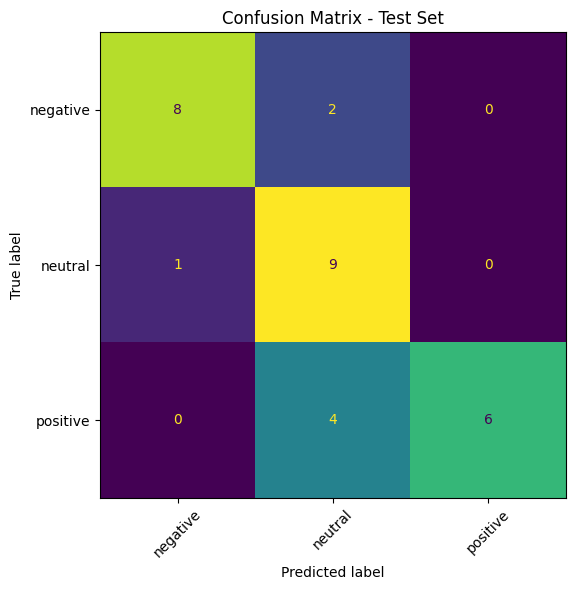

In [ ]:
# =========================================================
# Final test evaluation of the selected model
# This block evaluates only on test data and shows:
# - overall test metrics
# - positive-class metrics
# - classification report
# - confusion matrix
# =========================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Prepare test inputs
# ---------------------------------------------------------
test_cat = test_df[["issue_area_id", "issue_category_id"]].values
test_num = test_df[SELECTED_NUMERIC_COLS].values

# ---------------------------------------------------------
# Build test dataset
# ---------------------------------------------------------
test_dataset = FlexibleFusionDataset(
    encodings=test_encodings,
    labels=test_df["label"].values,
    cat_features=test_cat,
    num_features=test_num
)

# ---------------------------------------------------------
# Evaluate on test set
# ---------------------------------------------------------
test_metrics = best_trainer.evaluate(eval_dataset=test_dataset)

# Detailed predictions
test_results = evaluate_split(best_trainer, test_dataset, "test", label_encoder)

# Positive-class metrics
test_pos = get_positive_class_metrics(
    test_results["y_true"],
    test_results["y_pred"],
    label_encoder
)

# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------
cm = confusion_matrix(test_results["y_true"], test_results["y_pred"])

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Test Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

The final model achieved a macro F1 score of 0.77 on the test set.
Importantly, the model demonstrated strong precision for the positive class (1.00), indicating no false positive predictions.
Although recall for the positive class decreased to 0.60, analysis of the confusion matrix shows that misclassifications occurred primarily between the positive and neutral classes rather than with the negative class, which is a desirable error pattern.